# ДЗ-4

**функция:** $f(x) = |\mathrm{tg}(x)|^{x} \cdot \sin(x) + \dfrac{1}{2}$, отрезок $[-2, 1]$.

**полином Лагранжа:** $Q_3(x) = -0.02 x^{3} + 0.3851 x^{2} + 0.9454 x + 0.5$, узлы $x_0 = -2,\ x_1 = -1,\ x_2 = 0,\ x_3 = 1$.

---

#### постановка задачи

1. найти первую и вторую производные функции $f(x)$ в узлах разбиения
2. найти первую и вторую производные полинома Лагранжа $Q_3(x)$ из ДЗ-1 и вычислить их значения в узлах разбиения
3. сравнить.

исходная функция аппроксимируется интерполяционным полиномом, $f(x) = Q_m(x) + R_m(x)$, и производная функции приближённо заменяется производной полинома:

$$\frac{df(x_k)}{dx} \approx \frac{dQ_m(x_k)}{dx}.$$

**первая производная:**

$$\frac{df(x_k)}{dx} \approx \frac{-3 f_k + 4 f_{k+1} - f_{k+2}}{2h} \quad$$

$$\frac{df(x_{k+1})}{dx} \approx \frac{f_{k+2} - f_k}{2h} \quad $$

$$\frac{df(x_{k+2})}{dx} \approx \frac{3 f_{k+2} - 4 f_{k+1} + f_k}{2h}$$

**вторая производная**:

$$\frac{d^2 f(x_{k+1})}{dx^2} \approx \frac{f_{k+2} - 2 f_{k+1} + f_k}{h^2}.$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    x = np.asarray(x, dtype=float)
    result = np.empty_like(x)
    for i, xi in enumerate(x.flat):
        if abs(xi) < 1e-12:
            result.flat[i] = 0.5
        elif abs(np.cos(xi)) < 1e-8:
            result.flat[i] = np.nan
        else:
            tg = np.tan(xi)
            result.flat[i] = (np.abs(tg) ** xi) * np.sin(xi) + 0.5
    return result

#### численное дифференцирование функции

Используем разбиение 4 равноотстоящих узла на $[-2, 1]$ с шагом $h = 1$. 

In [3]:
a, b = -2, 1
x_nodes = np.linspace(a, b, 4)
h = x_nodes[1] - x_nodes[0]
f_nodes = f(x_nodes)

print('узлы и значения функции:')
for i in range(4):
    print(f'  x_{i} = {x_nodes[i]:.0f},  f(x_{i}) = {f_nodes[i]:.4f}')
print(f'  шаг h = {h:.0f}')

узлы и значения функции:
  x_0 = -2,  f(x_0) = 0.3095
  x_1 = -1,  f(x_1) = -0.0403
  x_2 = 0,  f(x_2) = 0.5000
  x_3 = 1,  f(x_3) = 1.8105
  шаг h = 1


#### первая производная

In [4]:
f0, f1, f2, f3 = f_nodes

d1_num = np.zeros(4)
d1_num[0] = (-3*f0 + 4*f1 - f2) / (2*h)
d1_num[1] = (f2 - f0) / (2*h)
d1_num[2] = (f3 - f1) / (2*h)
d1_num[3] = (3*f3 - 4*f2 + f1) / (2*h)

print('численная первая производная:')
for i in range(4):
    print(f"  f'(x_{i}) = f'({x_nodes[i]:.0f}) ≈ {d1_num[i]:.4f}")

численная первая производная:
  f'(x_0) = f'(-2) ≈ -0.7949
  f'(x_1) = f'(-1) ≈ 0.0952
  f'(x_2) = f'(0) ≈ 0.9254
  f'(x_3) = f'(1) ≈ 1.6956


#### вторая производная

In [5]:
d2_num = np.zeros(4)
d2_num[0] = (f2 - 2*f1 + f0) / h**2
d2_num[1] = (f2 - 2*f1 + f0) / h**2
d2_num[2] = (f3 - 2*f2 + f1) / h**2
d2_num[3] = (f3 - 2*f2 + f1) / h**2

print('численная вторая производная:')
for i in range(4):
    print(f"  f''(x_{i}) = f''({x_nodes[i]:.0f}) ≈ {d2_num[i]:.4f}")

численная вторая производная:
  f''(x_0) = f''(-2) ≈ 0.8902
  f''(x_1) = f''(-1) ≈ 0.8902
  f''(x_2) = f''(0) ≈ 0.7702
  f''(x_3) = f''(1) ≈ 0.7702


#### дифференцирование полинома Лагранжа

полином:

$$Q_3(x) = -0.02 x^{3} + 0.3851 x^{2} + 0.9454 x + 0.5.$$

**первая производная:**

$$Q_3'(x) = 3 \cdot (-0.02) x^{2} + 2 \cdot 0.3851 \, x + 0.9454 = -0.06 x^{2} + 0.7702 x + 0.9454.$$

**вторая производная:**

$$Q_3''(x) = 2 \cdot (-0.06) x + 0.7702 = -0.12 x + 0.7702.$$

In [6]:
c3, c2, c1, c0 = -0.02, 0.3851, 0.9454, 0.5

def Q3_d1(x):
    return 3*c3*x**2 + 2*c2*x + c1 # -0.06 x^2 + 0.7702 x +  0.9454

def Q3_d2(x):
    return 6*c3*x + 2*c2 # -0.12 x + 0.7702

#### значения производных в узлах разбиения

In [7]:
d1_lag = Q3_d1(x_nodes)
d2_lag = Q3_d2(x_nodes)

print('первая производная полинома Лагранжа:')
for i in range(4):
    print(f"  Q3'({x_nodes[i]:.0f}) = {d1_lag[i]:.4f}")
print()
print('вторая производная полинома Лагранжа:')
for i in range(4):
    print(f"  Q3''({x_nodes[i]:.0f}) = {d2_lag[i]:.4f}")

первая производная полинома Лагранжа:
  Q3'(-2) = -0.8350
  Q3'(-1) = 0.1152
  Q3'(0) = 0.9454
  Q3'(1) = 1.6556

вторая производная полинома Лагранжа:
  Q3''(-2) = 1.0102
  Q3''(-1) = 0.8902
  Q3''(0) = 0.7702
  Q3''(1) = 0.6502


#### сравнение

дополнительно посчитаем эталонную производную $f(x)$ численно с малым шагом (центральная разность, $h_{\text{ref}} = 10^{-5}$).

In [8]:
def f_d1_ref(x, hh=1e-5):
    return (f(x + hh) - f(x - hh)) / (2*hh)

def f_d2_ref(x, hh=1e-4):
    return (f(x + hh) - 2*f(x) + f(x - hh)) / hh**2

d1_ref = f_d1_ref(x_nodes)
d2_ref = f_d2_ref(x_nodes)

print('эталонная производная:')
for i in range(4):
    print(f"  x={x_nodes[i]:.0f}:  f'={d1_ref[i]:8.4f},  f''={d2_ref[i]:9.4f}")

эталонная производная:
  x=-2:  f'=  0.7706,  f''=  -2.1554
  x=-1:  f'= -1.0808,  f''=   2.0655
  x=0:  f'=  1.0000,  f''= -18.4207
  x=1:  f'=  4.3045,  f''=  20.6912


In [9]:
print('ПЕРВАЯ ПРОИЗВОДНАЯ')
print(f"{'x':>4}{'f числ':>12}{'Q3 аналит':>12}{'|разница|':>12}{'эталон':>12}")
for i in range(4):
    diff = abs(d1_num[i] - d1_lag[i])
    print(f"{x_nodes[i]:>4.0f}{d1_num[i]:>12.4f}{d1_lag[i]:>12.4f}{diff:>12.4f}{d1_ref[i]:>12.4f}")

ПЕРВАЯ ПРОИЗВОДНАЯ
   x      f числ   Q3 аналит   |разница|      эталон
  -2     -0.7949     -0.8350      0.0401      0.7706
  -1      0.0952      0.1152      0.0200     -1.0808
   0      0.9254      0.9454      0.0200      1.0000
   1      1.6956      1.6556      0.0400      4.3045


In [10]:
print('ВТОРАЯ ПРОИЗВОДНАЯ')
print(f"{'x':>4}{'f числ':>12}{'Q3 аналит':>12}{'|разница|':>12}{'эталон':>12}")
for i in range(4):
    diff = abs(d2_num[i] - d2_lag[i])
    print(f"{x_nodes[i]:>4.0f}{d2_num[i]:>12.4f}{d2_lag[i]:>12.4f}{diff:>12.4f}{d2_ref[i]:>12.4f}")

ВТОРАЯ ПРОИЗВОДНАЯ
   x      f числ   Q3 аналит   |разница|      эталон
  -2      0.8902      1.0102      0.1200     -2.1554
  -1      0.8902      0.8902      0.0000      2.0655
   0      0.7702      0.7702      0.0000    -18.4207
   1      0.7702      0.6502      0.1200     20.6912


### 5.4. Графики

построены аналитическая производная полинома $Q_3$ , численная производная функции в узлах и эталонная производная функции. (.) попадающие в окрестность асимптоты тангенса $x = -\pi/2 \approx -1.57$, на эталонной кривой пропускаем.

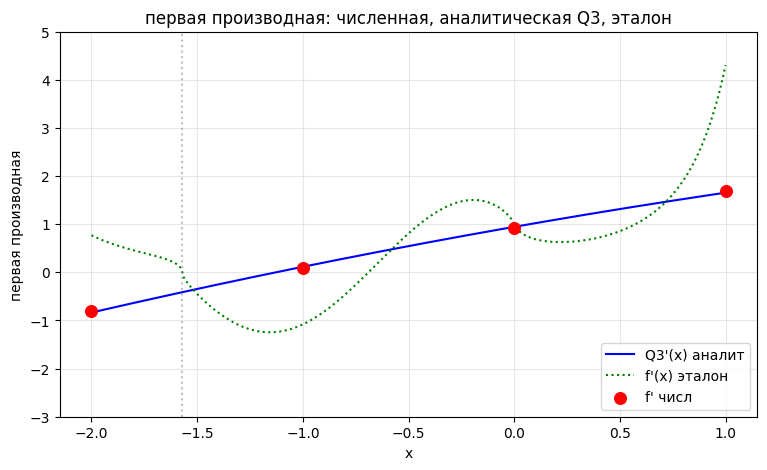

In [11]:
t = np.linspace(a, b, 400)
Q3_d1_curve = Q3_d1(t)
Q3_d2_curve = Q3_d2(t)
f_d1_curve = f_d1_ref(t)
f_d2_curve = f_d2_ref(t)

plt.figure(figsize=(9, 5))
plt.plot(t, Q3_d1_curve, 'b-', label="Q3'(x) аналит")
plt.plot(t, f_d1_curve, 'g:', label="f'(x) эталон")
plt.scatter(x_nodes, d1_num, color='red', s=70, zorder=5, label="f' числ")
plt.axvline(-np.pi/2, color='gray', ls=':', alpha=0.5)
plt.ylim(-3, 5)
plt.xlabel('x')
plt.ylabel("первая производная")
plt.title('первая производная: численная, аналитическая Q3, эталон')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

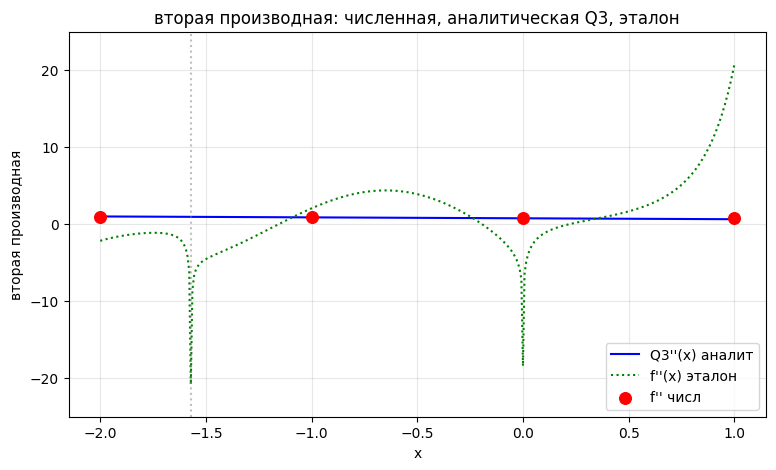

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(t, Q3_d2_curve, 'b-', label="Q3''(x) аналит")
plt.plot(t, f_d2_curve, 'g:', label="f''(x) эталон")
plt.scatter(x_nodes, d2_num, color='red', s=70, zorder=5, label="f'' числ")
plt.axvline(-np.pi/2, color='gray', ls=':', alpha=0.5)
plt.ylim(-25, 25)
plt.xlabel('x')
plt.ylabel("вторая производная")
plt.title('вторая производная: численная, аналитическая Q3, эталон')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()